### Задание 1

вариант 15 == 1

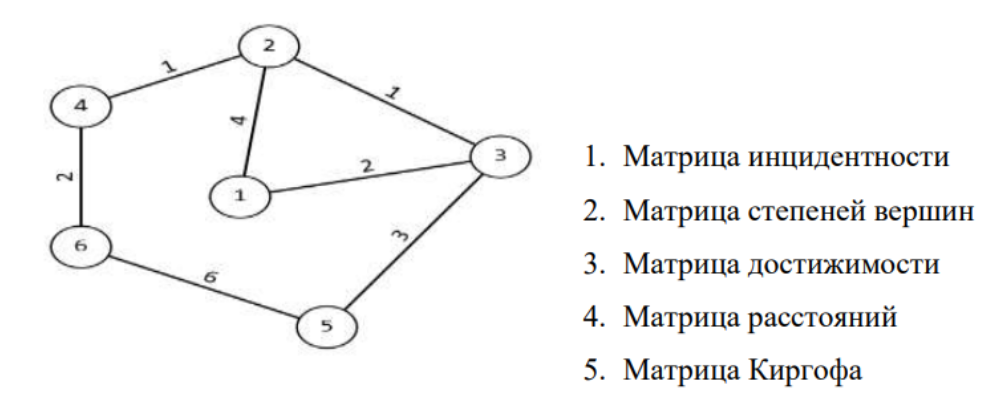

In [3]:
matrix = [
    [0, 4, 2, 0, 0, 0],
    [4, 0, 1, 1, 0, 0],
    [2, 1, 0, 0, 3, 0],
    [0, 1, 0, 0, 0, 2],
    [0, 0, 3, 0, 0, 6],
    [0, 0, 0, 2, 6, 0]
]

In [4]:
count_v = len(matrix)
count_v

6

In [5]:
def count_e_func(matrix) -> int:
    count = 0
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if i > j and matrix[i][j] != 0:
                count += 1
    return count
    

In [6]:
def get_e(matrix):
    e = []
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if matrix[i][j] != 0:
                if ((i, j) not in e) and ((j, i) not in e):
                    e.append((i, j))
    return e


In [7]:
e = get_e(matrix)
e

[(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 5), (4, 5)]

In [8]:
count_e = count_e_func(matrix)
count_e

7

#### 1. матрица инцидентности

In [9]:
def get_matrix_inqid(matrix):
    new_mat = [[0] * count_e for _ in range(count_v)]
    for k in range(count_e):
        i, j = e[k]
        new_mat[i][k] = 1
        new_mat[j][k] = 1
    return new_mat
        

In [10]:
matrix_inqid = get_matrix_inqid(matrix)
matrix_inqid

[[1, 1, 0, 0, 0, 0, 0],
 [1, 0, 1, 1, 0, 0, 0],
 [0, 1, 1, 0, 1, 0, 0],
 [0, 0, 0, 1, 0, 1, 0],
 [0, 0, 0, 0, 1, 0, 1],
 [0, 0, 0, 0, 0, 1, 1]]

#### 2. Матрица степеней вершин

In [11]:
def get_matrix_ver(matrix):
    new_mat = [[0] * count_v for _ in range(count_v)]
    for i in range(count_v):
        new_mat[i][i] = sum(matrix[i])
    return new_mat
        

In [12]:
matrix_ver = get_matrix_ver(matrix)
matrix_ver

[[6, 0, 0, 0, 0, 0],
 [0, 6, 0, 0, 0, 0],
 [0, 0, 6, 0, 0, 0],
 [0, 0, 0, 3, 0, 0],
 [0, 0, 0, 0, 9, 0],
 [0, 0, 0, 0, 0, 8]]

#### 3. Матрица достижимости

""Если граф связный (число компонент связности равно 1) и
неориентированный, все элементы матрицы достижимости равны единице.""

In [13]:
matrix_dostig = [[1] * count_v] * count_v
matrix_dostig

[[1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1]]

#### 4. Матрица расстояний

In [14]:
def get_matrix_distance(matrix, start):
    visited = [False] * count_v
    distance = [100] * count_v
    distance[start] = 0
    for _ in range(count_v):
        v = -1
        min_d = 100
        for i in range(count_v): # перебираем непосещенные вершины и выбираем ту, до которой минимальное растояние
            if not visited[i] and distance[i] < min_d:
                min_d = distance[i]
                v = i # вершина, растояние до которой минимально

        if v == -1:
            break
        visited[v] = True
        
        for i in range(count_v): # берем строчку по вершине из пред. цикла из матрицы
            if matrix[v][i] != 0 and not visited[i]: # если в вершину есть дорога и мы ее еще не смотрели
                if distance[v] + matrix[v][i] < distance[i]: # то смотрим будет ли новый маршрут короче старого
                    distance[i] = distance[v] + matrix[v][i]

    return distance         


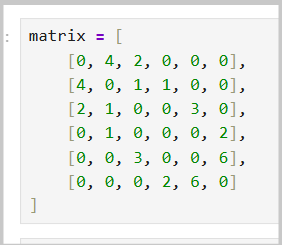


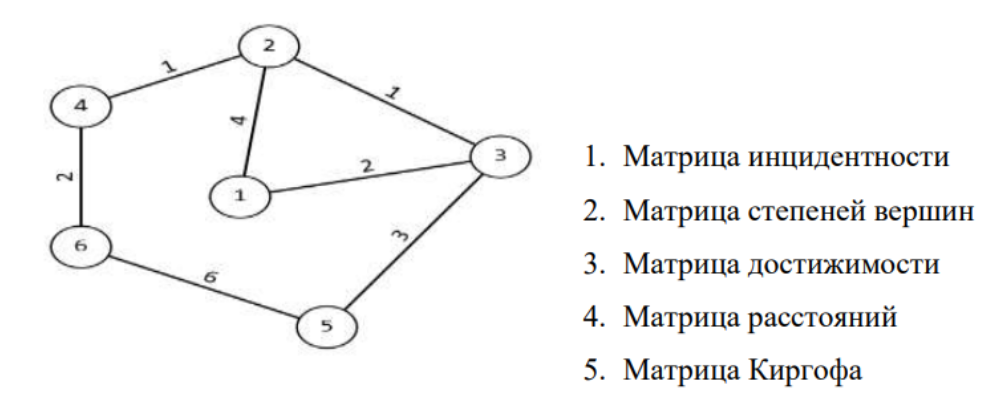

In [15]:
matrix_distance = []
for i in range(count_v):
    matrix_distance.append(get_matrix_distance(matrix, i))

matrix_distance

[[0, 3, 2, 4, 5, 6],
 [3, 0, 1, 1, 4, 3],
 [2, 1, 0, 2, 3, 4],
 [4, 1, 2, 0, 5, 2],
 [5, 4, 3, 5, 0, 6],
 [6, 3, 4, 2, 6, 0]]

#### 5. Матрица Киргофа

In [32]:
def get_matrix_kirgof(matrix):
    matrix_ver = get_matrix_ver(matrix)
    for i in range(count_v):
        for j in range(count_v):
            if i != j:
                matrix_ver[i][j] = matrix_ver[i][j] - matrix[i][j]
    return matrix_ver

In [33]:
matrix_kirgof = get_matrix_kirgof(matrix)
matrix_kirgof

[[6, -4, -2, 0, 0, 0],
 [-4, 6, -1, -1, 0, 0],
 [-2, -1, 6, 0, -3, 0],
 [0, -1, 0, 3, 0, -2],
 [0, 0, -3, 0, 9, -6],
 [0, 0, 0, -2, -6, 8]]

### Задание 2

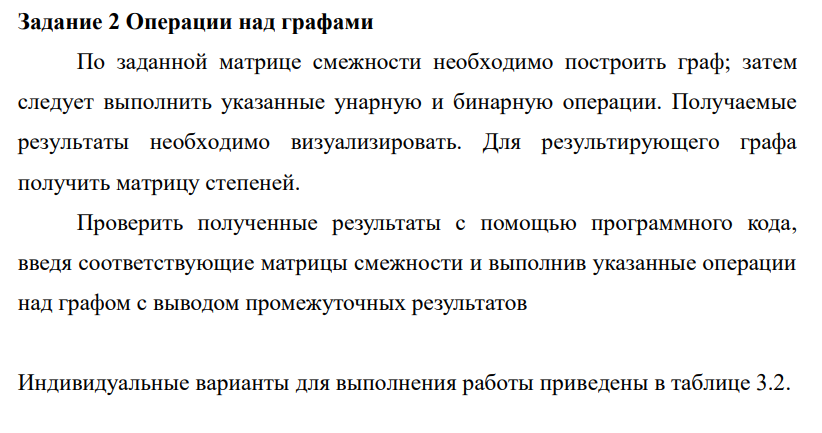

вариант 15 == 7

Что такое композиция $G_1[G_2]$ на самом деле?

Представь это так:

1. У тебя есть «главный» граф $G_1$ (например, карта городов).
2. Ты берешь каждую вершину (город) из $G_1$ и **заменяешь** её на целую копию графа $G_2$ (например, план квартала внутри города).

**Почему вершин становится больше?**
Потому что в каждом «городе» из $G_1$ теперь живет столько «зданий», сколько вершин в $G_2$.

* Если в $G_1$ было 4 вершины, а в $G_2$ — 2, то итоговых вершин будет 8.

**Как соединяются вершины (те самые два условия из методички):**

1. **Условие 1 («Между городами»):** Если два ***города*** в $G_1$ были соединены дорогой, то **все** ***здания*** из первого города соединяются со **всеми** зданиями из второго города.
2. **Условие 2 («Внутри города»):** Внутри одного города два здания соединяются только в том случае, если они были соединены в исходном плане $G_2$.


In [16]:
import numpy as np

# Граф G1 после унарной операции
M1_un = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 1],
    [0, 1, 0, 1],
    [0, 1, 1, 0]
])

# Граф G2
M2 = np.array([
    [0, 1],
    [1, 0]
])

def lexicographical_product(m1, m2):
    n1 = len(m1)
    n2 = len(m2)
    N = n1 * n2
    res = np.zeros((N, N), dtype=int)
    
    for i in range(n1):
        for j in range(n1):
            # Условие 1: Если вершины i и j смежны в G1,
            # соединяем все вершины их копий
            if m1[i, j] == 1:
                res[i*n2:(i+1)*n2, j*n2:(j+1)*n2] = 1
            # Условие 2: Если это одна и та же вершина i=j,
            # используем внутренние связи из G2
            elif i == j:
                res[i*n2:(i+1)*n2, i*n2:(i+1)*n2] = m2
    return res

M_final = lexicographical_product(M1_un, M2)
degrees = np.sum(M_final, axis=1)
D_matrix = np.diag(degrees)

print("Размер итоговой матрицы:", M_final.shape)
print("Степени вершин:", degrees)
print("\nМатрица степеней D:\n", D_matrix)


Размер итоговой матрицы: (8, 8)
Степени вершин: [3 3 7 7 5 5 5 5]

Матрица степеней D:
 [[3 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0]
 [0 0 7 0 0 0 0 0]
 [0 0 0 7 0 0 0 0]
 [0 0 0 0 5 0 0 0]
 [0 0 0 0 0 5 0 0]
 [0 0 0 0 0 0 5 0]
 [0 0 0 0 0 0 0 5]]
